<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/alba_Autoencoder_ReBeat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load data

In [1]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

In [2]:
import numpy as np
import scipy.io as sio
import os
from scipy.signal import find_peaks

# ---- Load subjects and parameters ----
subjects = ['1','2','3','4','5', '6', '7', '8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24']
tasks = ['CW', 'BL']

fs = 250  # Hz
pre_r = int(0.2 * fs)   # 50 samples
post_r = int(0.6 * fs)  # 150 samples
segment_len = pre_r + post_r  # 200 samples

autoencoder_segments = []

for subject in subjects:
    for task in tasks:
        try:
            # ---- Load files ----
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'

            data_filtered = sio.loadmat(path_filtered)
            ecg_filtered = data_filtered['ECG'].squeeze()
            icg_filtered = data_filtered['ICG'].squeeze()

            # ---- Detect R-peaks ----
            r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered)) #it works

            # ---- Extract segments around each R-peak ----
            for r in r_peaks:
                start = r - pre_r
                end = r + post_r
                if start < 0 or end > len(icg_filtered):
                    continue
                segment = icg_filtered[start:end]
                if len(segment) != segment_len:
                    continue

                autoencoder_segments.append(segment)

            print(f"Loaded Subject {subject} Task {task}: {len(r_peaks)} R-peaks")

        except Exception as e:
            print(f"Skipping Subject {subject} Task {task}: {e}")

# ---- Final formatting ----
X_auto = np.array(autoencoder_segments)  # shape: (n_samples, 174)

# Normalize each segment individually
X_auto = (X_auto - X_auto.mean(axis=1, keepdims=True)) / (X_auto.std(axis=1, keepdims=True) + 1e-8)

# Add channel dimension for the model: (n_samples, 174, 1)
X_auto = X_auto[..., np.newaxis]

# ---- Save for training the autoencoder ----
np.save("X_icg_autoencoder_input.npy", X_auto)
print(f"\nPrepared {X_auto.shape[0]} segments for autoencoder training.")


Loaded Subject 1 Task CW: 309 R-peaks
Loaded Subject 1 Task BL: 301 R-peaks
Loaded Subject 2 Task CW: 306 R-peaks
Loaded Subject 2 Task BL: 312 R-peaks
Loaded Subject 3 Task CW: 369 R-peaks
Loaded Subject 3 Task BL: 375 R-peaks
Loaded Subject 4 Task CW: 407 R-peaks
Loaded Subject 4 Task BL: 416 R-peaks
Loaded Subject 5 Task CW: 433 R-peaks
Loaded Subject 5 Task BL: 404 R-peaks
Loaded Subject 6 Task CW: 339 R-peaks
Loaded Subject 6 Task BL: 355 R-peaks
Loaded Subject 7 Task CW: 326 R-peaks
Loaded Subject 7 Task BL: 342 R-peaks
Loaded Subject 8 Task CW: 389 R-peaks
Loaded Subject 8 Task BL: 387 R-peaks
Loaded Subject 9 Task CW: 408 R-peaks
Loaded Subject 9 Task BL: 400 R-peaks
Loaded Subject 10 Task CW: 318 R-peaks
Loaded Subject 10 Task BL: 314 R-peaks
Loaded Subject 11 Task CW: 430 R-peaks
Loaded Subject 11 Task BL: 391 R-peaks
Loaded Subject 12 Task CW: 339 R-peaks
Loaded Subject 12 Task BL: 359 R-peaks
Loaded Subject 13 Task CW: 320 R-peaks
Loaded Subject 13 Task BL: 334 R-peaks
Load

In [3]:
X_auto = np.load("X_icg_autoencoder_input.npy")
print(X_auto.shape)  # (num_segments, 200, 1)

(16953, 200, 1)


# Autoencoder v2
Because v1 is not cleaning, maybe because input data was too clean, we add some noise to training

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D

input_shape = (200, 1)

# Encoder
input_sig = Input(shape=input_shape)
x = Conv1D(32, 5, activation='relu', padding='same')(input_sig)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 5, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(8, 3, activation='relu', padding='same')(x)
encoded = MaxPooling1D(2, padding='same')(x)  # Shape: (25, 8)

# Decoder
x = Conv1D(8, 3, activation='relu', padding='same')(encoded)
x = UpSampling1D(2)(x)
x = Conv1D(16, 5, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1D(32, 5, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
decoded = Conv1D(1, 3, activation='linear', padding='same')(x)

autoencoder = Model(input_sig, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 16)        │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 8)          │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 50, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 16)         │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 200, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 200, 1)         │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,705 (26.19 KB)

 Trainable params: 6,705 (26.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
noise_level = 0.05
X_noisy = X_auto + noise_level * np.random.normal(size=X_auto.shape)

## Train the autoencoder

In [ ]:
# train the model
autoencoder.fit(
    X_noisy, X_auto,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    shuffle=True
)


Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - loss: 0.2103 - val_loss: 0.0126
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0185 - val_loss: 0.0072
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0111 - val_loss: 0.0051
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 0.0092 - val_loss: 0.0042
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 0.0079 - val_loss: 0.0039
Epoch 6/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 0.0075 - val_loss: 0.0034
Epoch 7/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0070 - val_loss: 0.0033
Epoch 8/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0067 - val_loss: 0.0032
Epoch 9/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.0063 - val_loss: 0.0030
Epoch 10/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 0.0063 - val_loss: 0.0029
Epoch 11/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0061 - val_loss: 0.0028
Epoch 12/50
239/239 ━━━━━━━━━━━━━━

## Saving autoencoder

In [ ]:
autoencoder.save("autoencoder_icg_v2.h5")

## Using autoencoder

In [ ]:
from google.colab import files
from tensorflow.keras.models import load_model

# Paso 1: Subir el archivo
uploaded = files.upload()

# Paso 2: Verifica el nombre exacto del archivo cargado
filename = list(uploaded.keys())[0]  # Esto te da el nombre real, por si se llama "autoencoder_icg_v2 (2).h5"

# Paso 3: Cargar el modelo desde el archivo
autoencoder = load_model(filename)


Saving autoencoder_icg_v2.h5 to autoencoder_icg_v2.h5


## We try the trained autoencoder on unannotated data

Detected 309 R-peaks
Extracted 307 ICG segments
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


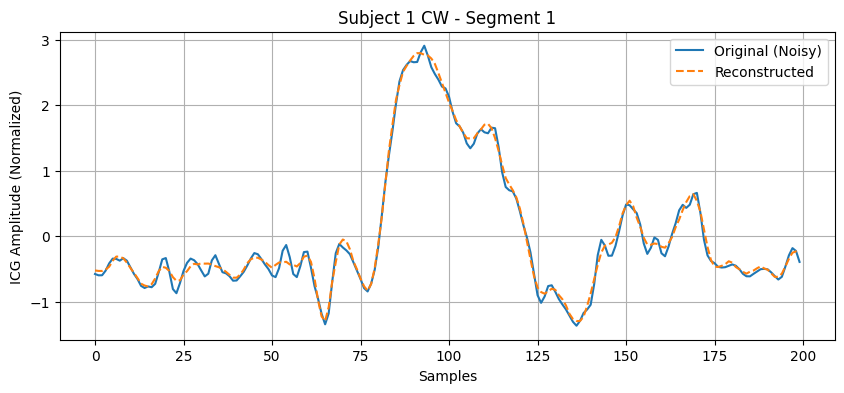

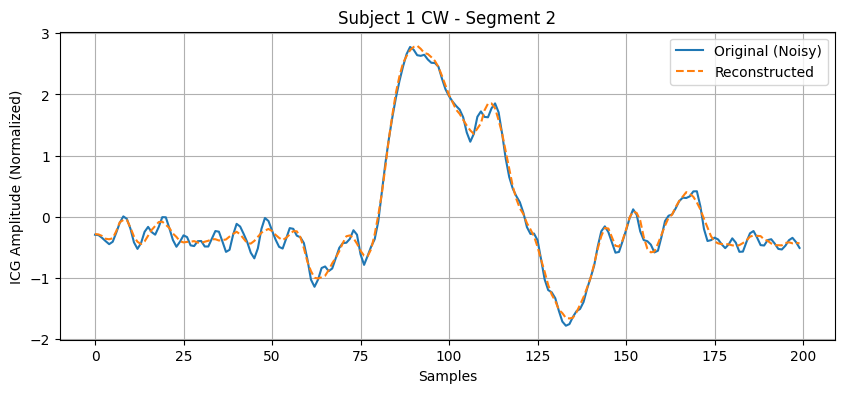

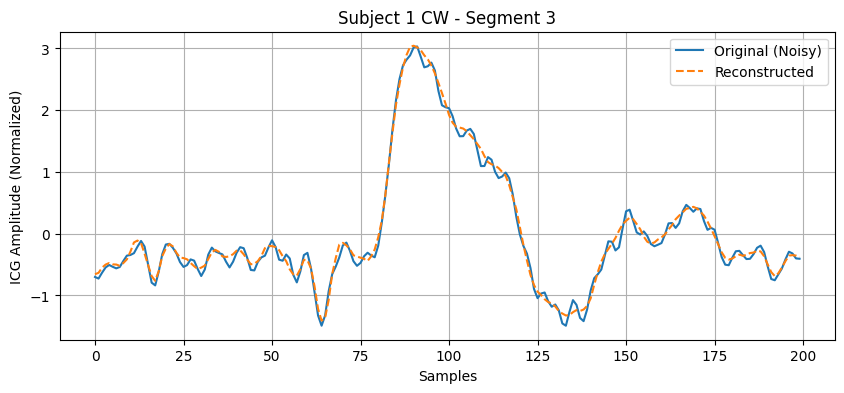

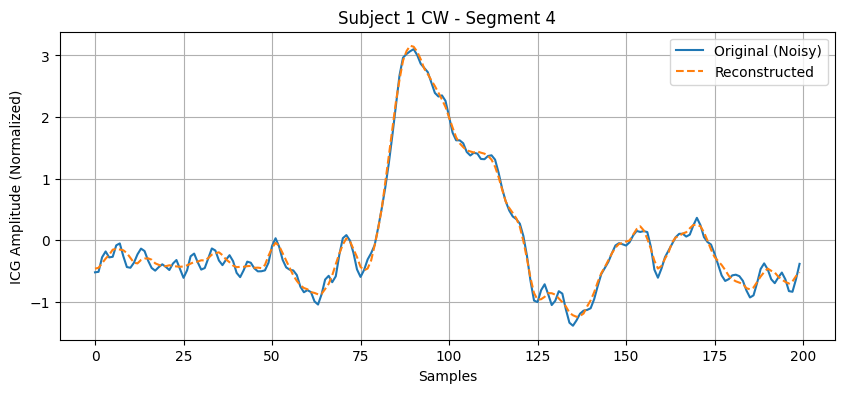

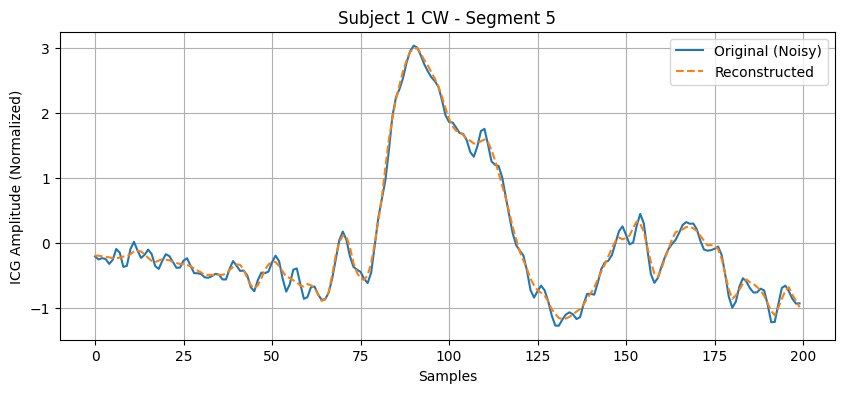

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tensorflow.keras.models import load_model

# ---- Load 1 subject's filtered data ----
subject = '1'
task = 'CW'

data_filtered = sio.loadmat(f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat')
ecg_filtered = data_filtered['ECG'].squeeze()
icg_filtered = data_filtered['ICG'].squeeze()
fs = int(data_filtered['samplFreq'].squeeze())  # should be 250 Hz

# ---- R-peak detection from ECG ----
distance = int(0.6 * fs)
r_peaks, _ = find_peaks(ecg_filtered, distance=distance, height=np.mean(ecg_filtered))
print(f"Detected {len(r_peaks)} R-peaks")

# ---- Segment ICG using R-peaks ----
pre_r = int(0.2 * fs)
post_r = int(0.6 * fs)
segment_len = pre_r + post_r  # 200 samples total

segments = []
valid_r_peaks = []

for r in r_peaks:
    start = r - pre_r
    end = r + post_r
    if start >= 0 and end < len(icg_filtered):
        segment = icg_filtered[start:end]
        if len(segment) == segment_len:
            segments.append(segment)
            valid_r_peaks.append(r)

print(f"Extracted {len(segments)} ICG segments")

# ---- Prepare segments for the autoencoder ----
X_unlabeled = np.array(segments)
X_unlabeled = (X_unlabeled - X_unlabeled.mean(axis=1, keepdims=True)) / (X_unlabeled.std(axis=1, keepdims=True) + 1e-8)
X_unlabeled = X_unlabeled[..., np.newaxis]  # shape: (n, 200, 1)

# ---- Load the trained autoencoder ----
autoencoder = load_model("autoencoder_icg_v2.h5", compile=False)

# ---- Reconstruct the segments ----
X_reconstructed = autoencoder.predict(X_unlabeled)

# ---- Plot a few input vs reconstructed signals ----
for i in range(5):
    plt.figure(figsize=(10, 4))
    plt.plot(X_unlabeled[i].squeeze(), label='Original (Noisy)')
    plt.plot(X_reconstructed[i].squeeze(), label='Reconstructed', linestyle='--')
    plt.title(f"Subject {subject} {task} - Segment {i+1}")
    plt.xlabel("Samples")
    plt.ylabel("ICG Amplitude (Normalized)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import numpy as np

def snr(original, reconstructed):
    noise = original - reconstructed
    signal_power = np.sum(original ** 2)
    noise_power = np.sum(noise ** 2)
    if noise_power == 0:
        return np.inf  # perfect reconstruction
    return 10 * np.log10(signal_power / noise_power)

# Example: use first 100 segments (or more if you like)
X_subset = X_auto[:100].squeeze(axis=-1)         # Shape: (100, 200)
X_recon_subset = X_reconstructed[:100].squeeze(axis=-1)

# Compute SNRs
snrs = [snr(orig, recon) for orig, recon in zip(X_subset, X_recon_subset)]
print(f"Average SNR: {np.mean(snrs):.2f} dB")


Average SNR: 21.20 dB


# Train another model v2 -> with early stopping

In [ ]:
import numpy as np
import scipy.io as sio
import os
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# ---- Load subjects and parameters ----
subjects = ['1','2','3','4','5', '6', '7', '8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24']
tasks = ['CW', 'BL']

fs = 250  # Hz
segment_len = 200
pre_r = int(0.2 * fs)   # 0.2s before R = 50 samples
post_r = int(0.6 * fs)  # 0.6s after R = 150 samples

all_segments = []
all_labels = []

for subject in subjects:
    for task in tasks:
        try:
            # ---- Load files ----
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'

            data_filtered = sio.loadmat(path_filtered)
            annotation = sio.loadmat(path_annotation)

            ecg_filtered = data_filtered['ECG'].squeeze()
            icg_filtered = data_filtered['ICG'].squeeze()
            annotations = annotation['annotPoints']

            # ---- Detect R-peaks ----
            r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))

            for r in r_peaks:
                start = r - pre_r
                end = r + post_r
                if start < 0 or end > len(icg_filtered):
                    continue

                icg_segment = icg_filtered[start:end]
                ecg_segment = ecg_filtered[start:end]

                if len(icg_segment) != segment_len or len(ecg_segment) != segment_len:
                    continue

                segment = np.stack((icg_segment, ecg_segment), axis=-1)  # Shape: [200, 2]

                for row in annotations:
                    b, c, x, o = row
                    if start <= b and o <= end:
                        relative = [b - start, c - start, x - start, o - start]
                        all_segments.append(segment)
                        all_labels.append(relative)
                        break  # avoid duplicates

            print(f"Loaded Subject {subject} Task {task}: {len(annotations)} annotations")

        except Exception as e:
            print(f"Skipping Subject {subject} Task {task}: {e}")

# ---- Final formatting ----
X = np.array(all_segments)  # shape: (n_samples, 200, 2)
y = np.array(all_labels)    # shape: (n_samples, 4)

# ---- Normalize per channel per sample ----
X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True) + 1e-8
X = (X - X_mean) / X_std

# ---- One-hot encode labels ----
n_samples = y.shape[0]
n_classes = 4  # B, C, X, O
y_onehot = np.zeros((n_samples, segment_len, n_classes), dtype=np.float32)

for i in range(n_samples):
    for class_idx, t in enumerate(y[i]):
        if 0 <= t < segment_len:
            y_onehot[i, t, class_idx] = 1.0

# ---- Save everything ----
np.save("X_icg_ecg_segments.npy", X)           # [n_samples, 200, 2]
np.save("y_icg_labels_original.npy", y)        # [n_samples, 4]
np.save("y_icg_labels_onehot.npy", y_onehot)   # [n_samples, 200, 4]

# ---- Preview ----
df_preview = pd.DataFrame(y[:10], columns=["B", "C", "X", "O"])
print("\nSample annotation preview (relative to R-aligned segment):")
print(df_preview)

# ---- Plot one-hot labels for a sample ----
sample_index = 0
labels = ["B", "C", "X", "O"]
time_steps = np.arange(segment_len)
time_ms = (time_steps - pre_r) * 1000 / fs  # Centered at R-peak

# plt.figure(figsize=(12, 3))
# for i in range(n_classes):
#     plt.plot(time_ms, y_onehot[sample_index, :, i], label=labels[i])
# plt.title("One-hot encoded labels (Sample 0)")
# plt.xlabel("Time (ms relative to R-peak)")
# plt.ylabel("Label")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Loaded Subject 1 Task CW: 40 annotations
Loaded Subject 1 Task BL: 40 annotations
Loaded Subject 2 Task CW: 39 annotations
Loaded Subject 2 Task BL: 40 annotations
Loaded Subject 3 Task CW: 40 annotations
Loaded Subject 3 Task BL: 40 annotations
Loaded Subject 4 Task CW: 40 annotations
Loaded Subject 4 Task BL: 40 annotations
Skipping Subject 5 Task CW: [Errno 2] No such file or directory: '/content/Annotations/Annotat_Subject_5_task_CW.mat'
Loaded Subject 5 Task BL: 71 annotations
Loaded Subject 6 Task CW: 40 annotations
Loaded Subject 6 Task BL: 39 annotations
Loaded Subject 7 Task CW: 40 annotations
Loaded Subject 7 Task BL: 40 annotations
Loaded Subject 8 Task CW: 40 annotations
Loaded Subject 8 Task BL: 40 annotations
Loaded Subject 9 Task CW: 40 annotations
Loaded Subject 9 Task BL: 40 annotations
Loaded Subject 10 Task CW: 40 annotations
Loaded Subject 10 Task BL: 40 annotations
Loaded Subject 11 Task CW: 40 annotations
Loaded Subject 11 Task BL: 40 annotations
Loaded Subject 12

In [ ]:
import numpy as np

def augment_batch(X, y, noise_std=0.01, amp_range=(0.9, 1.1), max_shift=2):
    X_aug = np.copy(X)
    y_aug = np.copy(y)

    for i in range(X.shape[0]):
        # --- Gaussian noise ---
        X_aug[i] += np.random.normal(0, noise_std, size=X[i].shape)

        # --- Amplitude scaling ---
        scale = np.random.uniform(*amp_range)
        X_aug[i] *= scale

        # --- Time shift ---
        shift = np.random.randint(-max_shift, max_shift + 1)
        if shift != 0:
            X_aug[i] = np.roll(X_aug[i], shift, axis=0)
            y_aug[i] = np.roll(y_aug[i], shift, axis=0)
            if shift > 0:
                y_aug[i, :shift] = 0
            else:
                y_aug[i, shift:] = 0

    return X_aug, y_aug


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Bidirectional, TimeDistributed, Dense

def build_model(input_shape=(200, 2), num_classes=4):
    inputs = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = TimeDistributed(Dense(64, activation='relu'))(x)
    outputs = TimeDistributed(Dense(num_classes, activation='softmax'))(x)

    model = Model(inputs, outputs)
    return model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Load data
X = np.load("X_icg_ecg_segments.npy")           # (n_samples, 200, 2)
y = np.load("y_icg_labels_onehot.npy")          # (n_samples, 200, 4)

# Split (simple example)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

# Build model
model = build_model(input_shape=(200, 2), num_classes=4)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Augment training data
X_train_aug, y_train_aug = augment_batch(X_train, y_train)

## Training

In [ ]:
# # ---- Early stopping callback ----
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

# # Train
# history = model.fit(
#     X_train_aug, y_train_aug,
#     validation_data=(X_val, y_val),
#     epochs=30,
#     callbacks=[early_stopping],
#     batch_size=32
# )

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 59s 711ms/step - accuracy: 0.1636 - loss: 0.0134 - val_accuracy: 0.3788 - val_loss: 0.0020
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 604ms/step - accuracy: 0.3769 - loss: 0.0014 - val_accuracy: 0.3968 - val_loss: 0.0013
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 595ms/step - accuracy: 0.3977 - loss: 8.4131e-04 - val_accuracy: 0.2632 - val_loss: 0.0013
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 43s 633ms/step - accuracy: 0.3335 - loss: 8.5665e-04 - val_accuracy: 0.3601 - val_loss: 0.0011
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 39s 590ms/step - accuracy: 0.3017 - loss: 9.2149e-04 - val_accuracy: 0.2715 - val_loss: 0.0015
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 592ms/step - accuracy: 0.2955 - loss: 0.0012 - val_accuracy: 0.3197 - val_loss: 0.0012
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 598ms/step - accuracy: 0.3177 - loss: 8.8801e-04 - val_accuracy: 0.3632 - val_loss: 0.0012
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 579ms/step - accuracy: 0.3363 - loss: 6

## Using the model

In [ ]:
from google.colab import files
model = files.upload()

Saving icg_detector_v1.h5 to icg_detector_v1.h5


In [ ]:
import numpy as np

def extract_predicted_points(y_pred):
    """
    Input:
        y_pred: np.array of shape (n_samples, 200, 4) with softmax outputs
    Returns:
        pred_points: np.array of shape (n_samples, 4), time indices of B, C, X, O
    """
    return np.argmax(y_pred, axis=1)  # shape: (n_samples, 4)


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('icg_detector_v1.h5')

y_pred = model.predict(X_val)  # shape: (n_samples, 200, 4)
predicted_points = extract_predicted_points(y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 655ms/step


In [ ]:
import matplotlib.pyplot as plt

def plot_prediction_vs_true(X_sample, y_true_onehot, y_pred_onehot, sample_index=0, fs=250, pre_r=50):
    """
    Visualizes true vs predicted labels on top of ICG signal
    """
    signal = X_sample[sample_index, :, 0]  # ICG signal
    time_steps = np.arange(signal.shape[0])
    time_ms = (time_steps - pre_r) * 1000 / fs

    true_points = np.argmax(y_true_onehot[sample_index], axis=1)
    pred_points = np.argmax(y_pred_onehot[sample_index], axis=1)

    labels = ["B", "C", "X", "O"]
    colors = ["blue", "orange", "green", "red"]

    plt.figure(figsize=(12, 4))
    plt.plot(time_ms, signal, label='ICG signal', color='black', linewidth=1)

    for class_id in range(4):
        true_t = np.argmax(y_true_onehot[sample_index, :, class_id])
        pred_t = np.argmax(y_pred_onehot[sample_index, :, class_id])

        plt.axvline((true_t - pre_r) * 1000 / fs, color=colors[class_id], linestyle='--', label=f'True {labels[class_id]}')
        plt.axvline((pred_t - pre_r) * 1000 / fs, color=colors[class_id], linestyle='-', alpha=0.6, label=f'Pred {labels[class_id]}')

    plt.title(f"Sample {sample_index}: True vs Predicted Characteristic Points")
    plt.xlabel("Time (ms relative to R-peak)")
    plt.ylabel("ICG amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


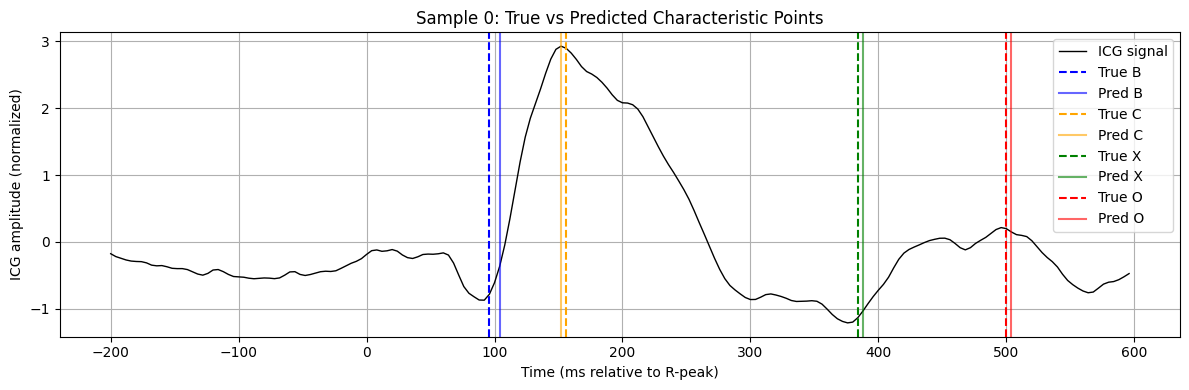

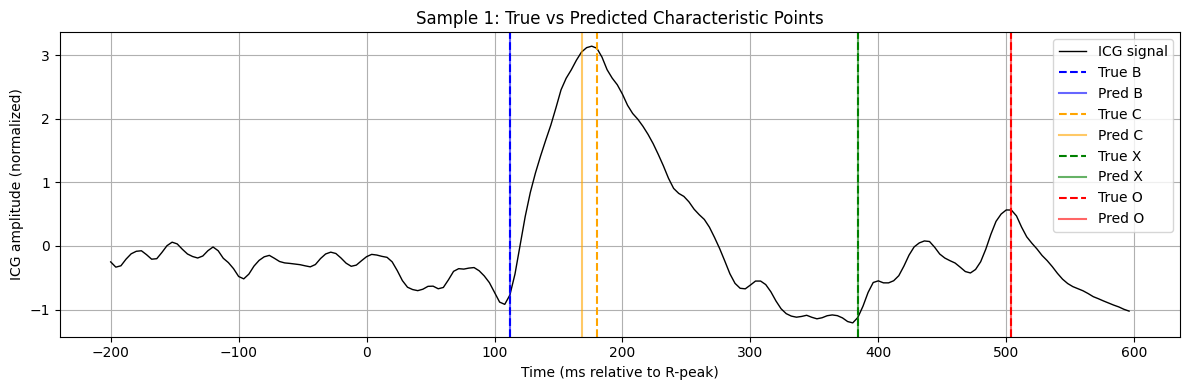

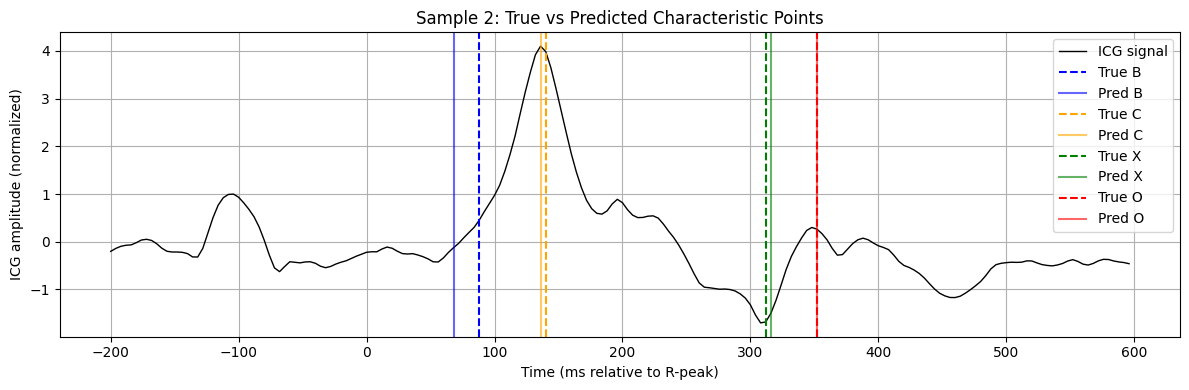

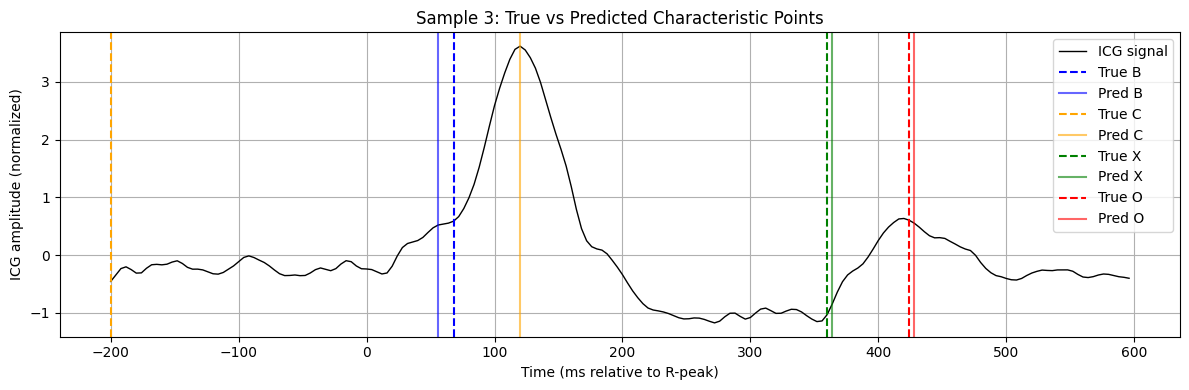

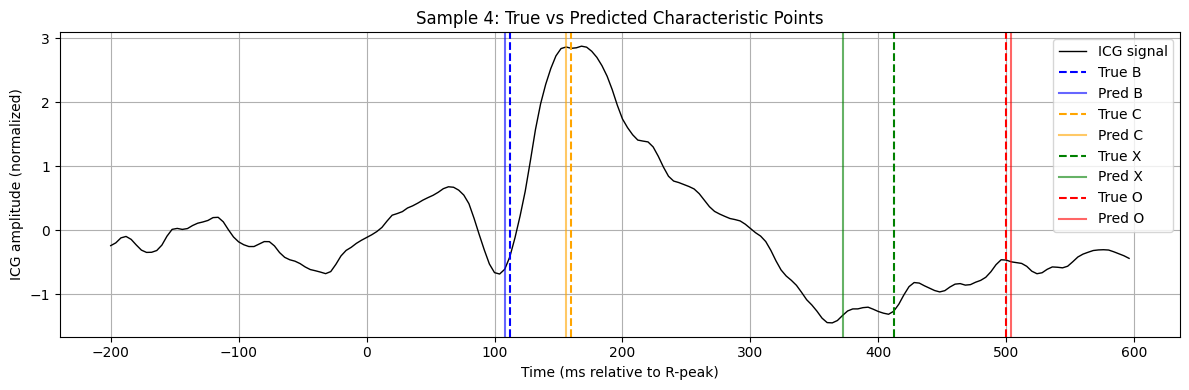

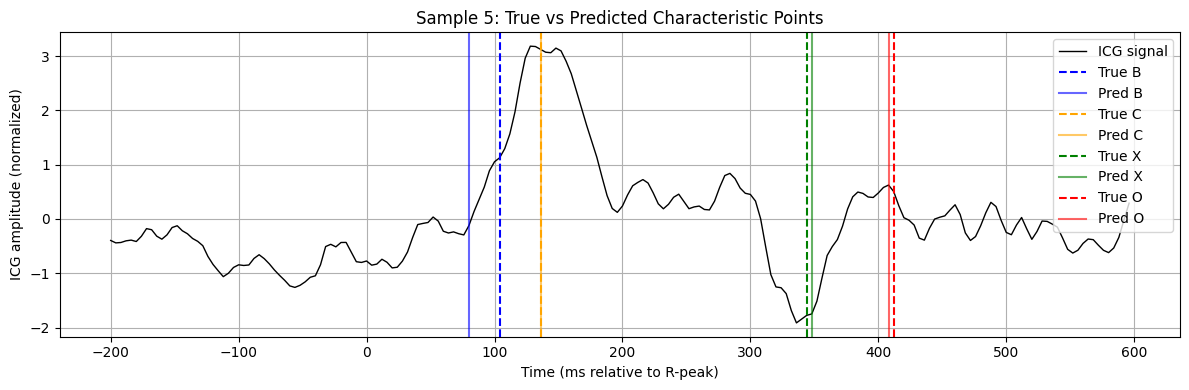

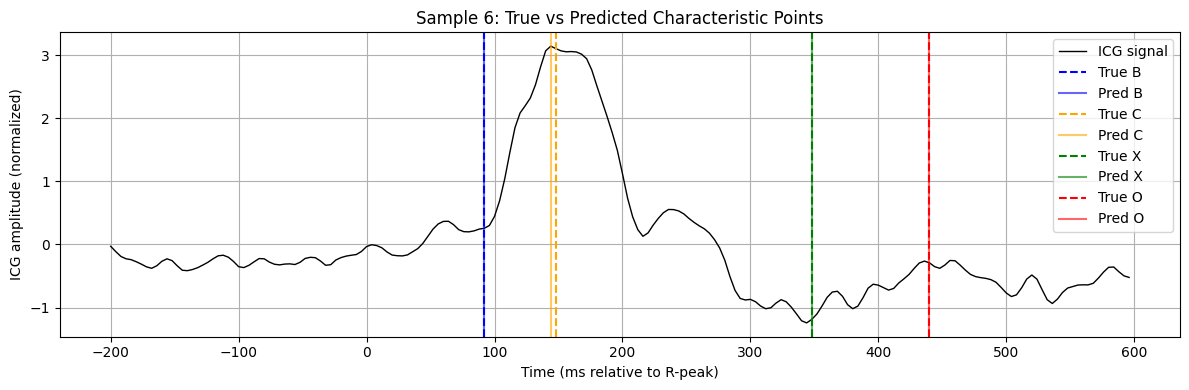

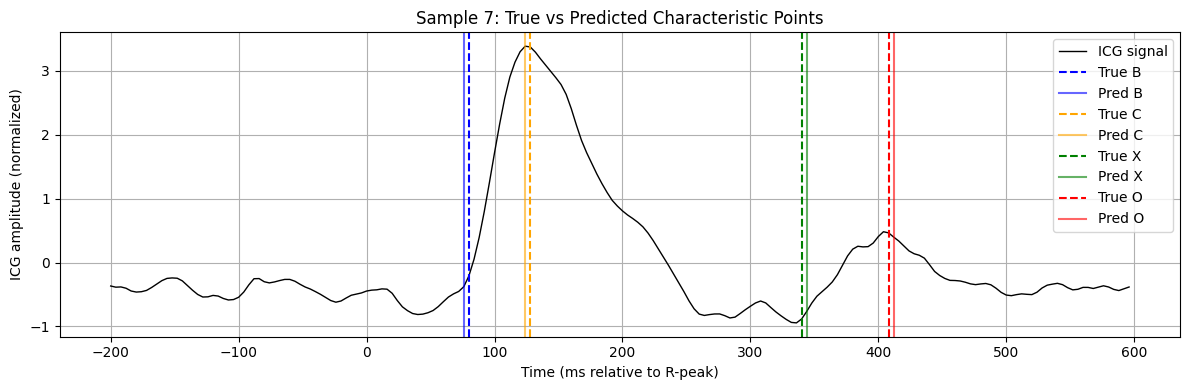

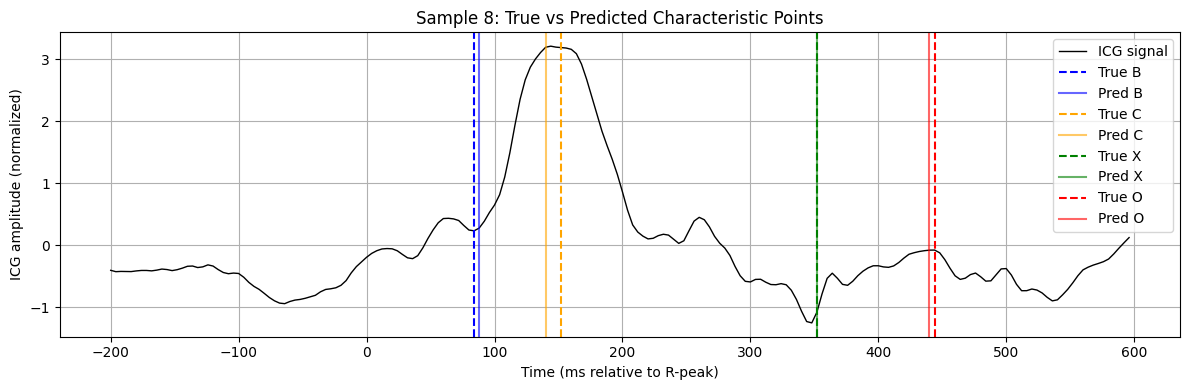

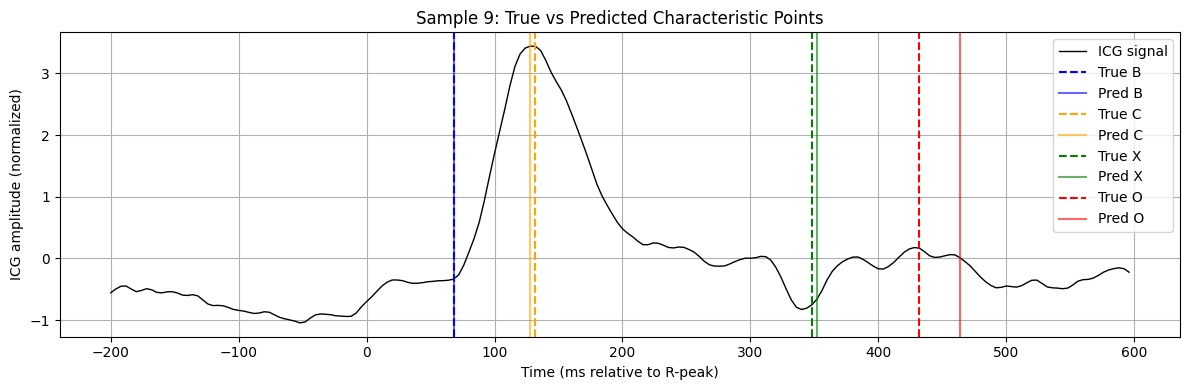

In [ ]:
for i in range(0,10):
  plot_prediction_vs_true(X_val, y_val, y_pred, sample_index=i)


### we evaluate if the model is good

Mean Absolute Error (MAE) measures, on average, how far the model's predictions are from the true values, ignoring the direction.

In [ ]:
import numpy as np

def compute_point_errors(y_true_onehot, y_pred_softmax, fs=250, unit="samples"):
    """
    Computes absolute error for each point type (B, C, X, O).

    Parameters:
        y_true_onehot: np.array of shape (n_samples, 200, 4) - one-hot true labels
        y_pred_softmax: np.array of shape (n_samples, 200, 4) - softmax predictions
        fs: sampling frequency in Hz (default = 250)
        unit: 'samples' or 'ms' (default = 'samples')

    Returns:
        A dictionary with mean absolute error for each point (and overall mean).
    """
    y_true_idx = np.argmax(y_true_onehot, axis=1)  # (n_samples, 4)
    y_pred_idx = np.argmax(y_pred_softmax, axis=1) # (n_samples, 4)

    sample_diff = np.abs(y_pred_idx - y_true_idx)

    if unit == "ms":
        diff = (sample_diff * 1000) / fs
    else:
        diff = sample_diff

    labels = ['B', 'C', 'X', 'O']
    errors = {lbl: diff[:, i].mean() for i, lbl in enumerate(labels)}
    errors['mean'] = diff.mean()

    return errors


In [ ]:
# After model.predict:
y_pred = model.predict(X_val)  # shape: (n_samples, 200, 4)
errors = compute_point_errors(y_val, y_pred, fs=250, unit="samples")
for point, err in errors.items():
    print(f"{point} point error: {err:.2f} samples")


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
B point error: 4.15 samples
C point error: 5.71 samples
X point error: 2.77 samples
O point error: 5.55 samples
mean point error: 4.54 samples


In [ ]:
model.save("icg_detector_v1.h5")
from google.colab import files
files.download("icg_detector_v1.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Trying on unannotated data

Detected 297 R-peaks
Extracted 295 segments
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 647ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


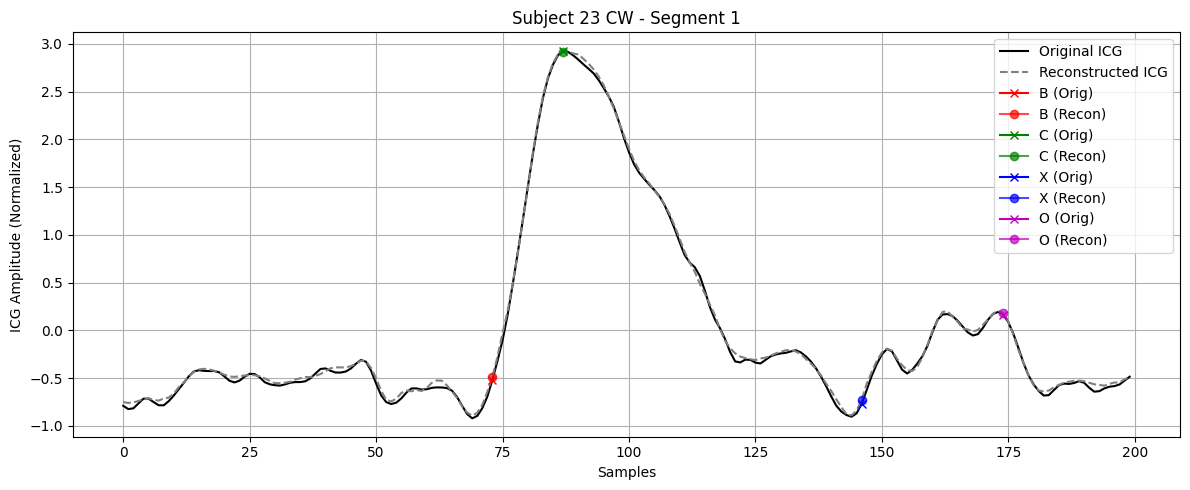

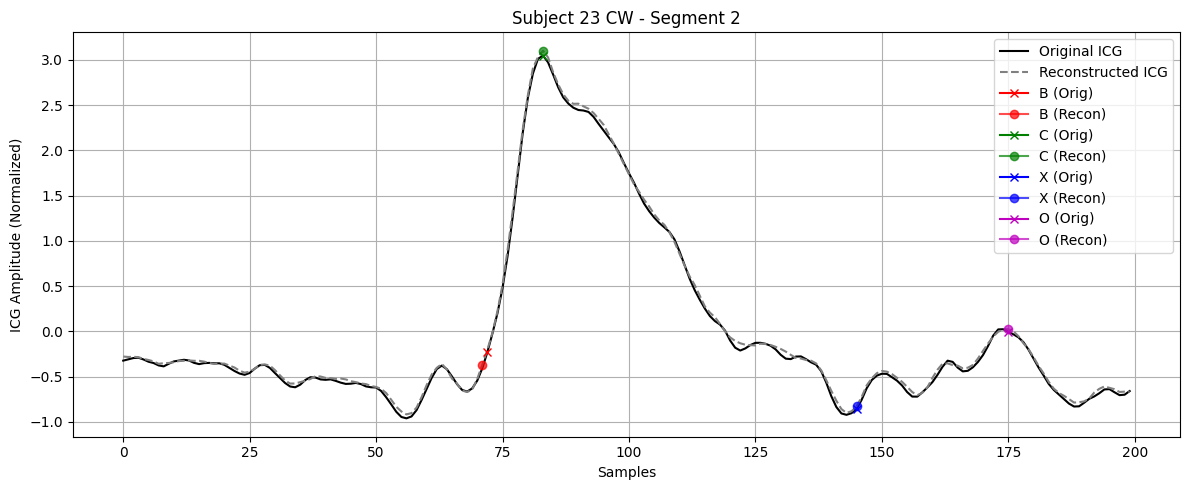

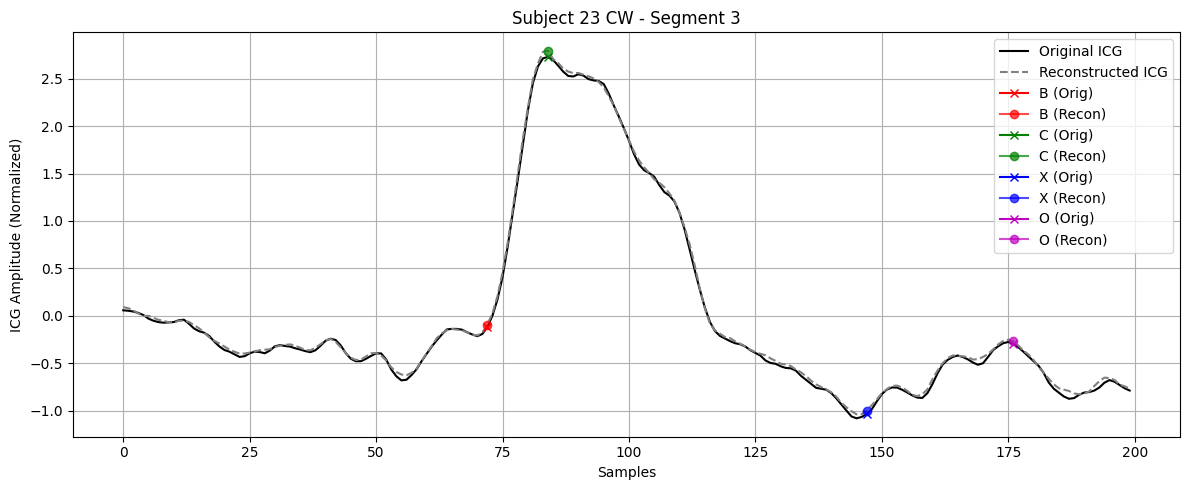

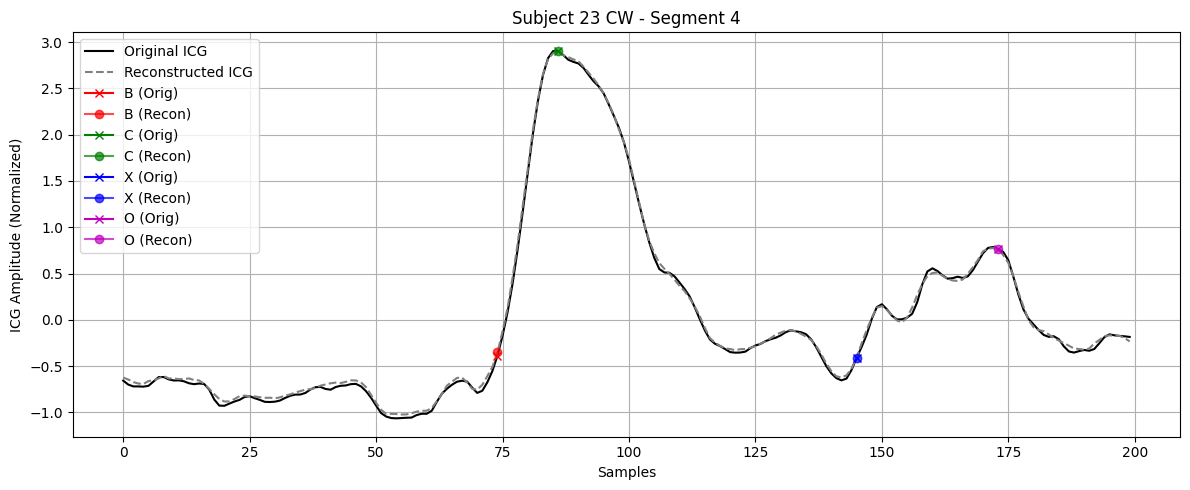

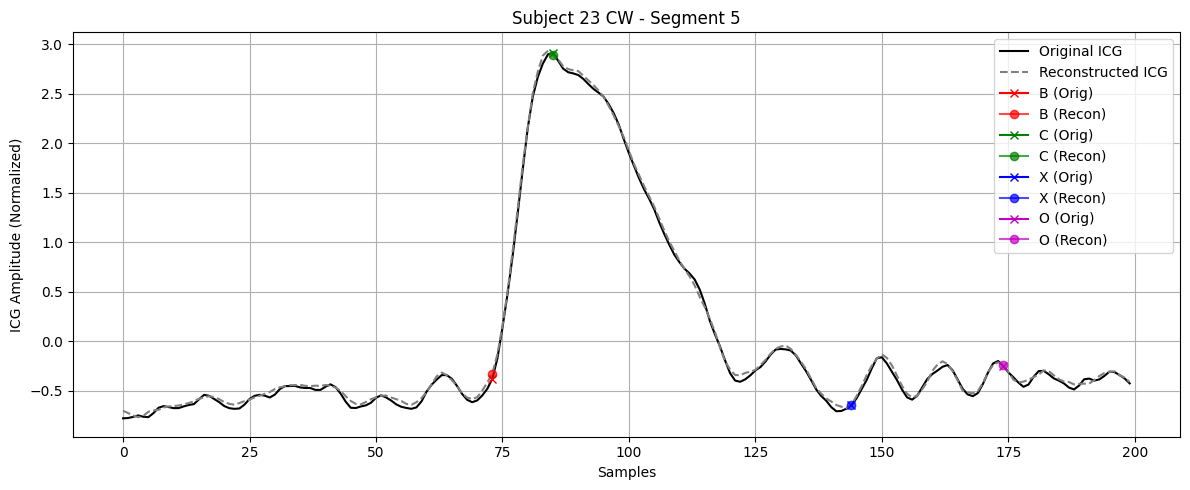

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tensorflow.keras.models import load_model

# ---- Load data ----
subject = '23'
task = 'CW'

data_filtered = sio.loadmat(f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat')
ecg_filtered = data_filtered['ECG'].squeeze()
icg_filtered = data_filtered['ICG'].squeeze()
fs = int(data_filtered['samplFreq'].squeeze())  # 250 Hz

# ---- R-peak detection ----
r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))
print(f"Detected {len(r_peaks)} R-peaks")

# ---- Segment ICG and ECG ----
pre_r = int(0.2 * fs)
post_r = int(0.6 * fs)
segment_len = pre_r + post_r

icg_segments = []
ecg_segments = []
valid_r_peaks = []

for r in r_peaks:
    start = r - pre_r
    end = r + post_r
    if start >= 0 and end < len(icg_filtered):
        icg_seg = icg_filtered[start:end]
        ecg_seg = ecg_filtered[start:end]
        if len(icg_seg) == segment_len and len(ecg_seg) == segment_len:
            icg_segments.append(icg_seg)
            ecg_segments.append(ecg_seg)
            valid_r_peaks.append(r)

print(f"Extracted {len(icg_segments)} segments")

# ---- Normalize ICG + ECG ----
X_icg = np.array(icg_segments)
X_icg_norm = (X_icg - X_icg.mean(axis=1, keepdims=True)) / (X_icg.std(axis=1, keepdims=True) + 1e-8)
X_icg_norm = X_icg_norm[..., np.newaxis]  # (n, 200, 1)

X_ecg = np.array(ecg_segments)
X_ecg_norm = (X_ecg - X_ecg.mean(axis=1, keepdims=True)) / (X_ecg.std(axis=1, keepdims=True) + 1e-8)
X_ecg_norm = X_ecg_norm[..., np.newaxis]  # (n, 200, 1)

# ---- Reconstruct ICG ----
autoencoder = load_model("autoencoder_icg_v2.h5", compile=False)
X_icg_recon = autoencoder.predict(X_icg_norm)

# ---- Build model inputs ----
X_original_input = np.concatenate([X_icg_norm, X_ecg_norm], axis=-1)
X_recon_input = np.concatenate([X_icg_recon, X_ecg_norm], axis=-1)

# ---- Load detector and predict both ----
detector = load_model("icg_detector_v1.h5", compile=False)

y_pred_orig = detector.predict(X_original_input)
y_pred_recon = detector.predict(X_recon_input)

pred_idx_orig = np.argmax(y_pred_orig, axis=1)   # (n, 4)
pred_idx_recon = np.argmax(y_pred_recon, axis=1) # (n, 4)

# ---- Compare visually ----
labels = ['B', 'C', 'X', 'O']
colors = ['r', 'g', 'b', 'm']

for i in range(min(5, len(X_icg))):
    orig_icg = X_icg_norm[i].squeeze()
    recon_icg = X_icg_recon[i].squeeze()
    pred_o = pred_idx_orig[i]
    pred_r = pred_idx_recon[i]

    plt.figure(figsize=(12, 5))
    plt.plot(orig_icg, label='Original ICG', color='black')
    plt.plot(recon_icg, label='Reconstructed ICG', color='gray', linestyle='--')

    for idx_o, idx_r, lbl, col in zip(pred_o, pred_r, labels, colors):
        if 0 <= idx_o < len(orig_icg):
            plt.plot(idx_o, orig_icg[idx_o], marker='x', color=col, label=f'{lbl} (Orig)')
        if 0 <= idx_r < len(recon_icg):
            plt.plot(idx_r, recon_icg[idx_r], marker='o', color=col, alpha=0.7, label=f'{lbl} (Recon)')

    plt.title(f"Subject {subject} {task} - Segment {i+1}")
    plt.xlabel("Samples")
    plt.ylabel("ICG Amplitude (Normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Train another model v3 -> with HeartCycle

In [4]:
import numpy as np
import scipy.io as sio
import os
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, savgol_filter, resample, find_peaks
from tensorflow.keras import layers, models

# Helper functions
def bandpass(data, fs, lowcut, highcut, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, fs, freq=50, quality_factor=30):
    b, a = iirnotch(freq, quality_factor, fs)
    return filtfilt(b, a, data)

def get_sampling_frequency(time_array):
    time_diffs = np.diff(time_array)
    avg_time_step = np.mean(time_diffs)
    fs = 1 / avg_time_step
    return fs

def preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)
    baseline = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)
    icg_detrended = icg_bandpassed - baseline
    return icg_detrended


In [5]:
def load_heartcycle_signals(file_path):
    data_hc = sio.loadmat(file_path)
    measures = data_hc['measure']

    # ICG
    icg = measures[1,1]
    icg_time = icg['time'][0,0].flatten()
    icg_data = icg['data'][0,0].flatten()
    fs_icg = get_sampling_frequency(icg_time)

    # ECG
    ecg_1 = measures[0,1]
    ecg_1_time = ecg_1['time'][0,0].flatten()
    ecg_1_data = ecg_1['data'][0,0].flatten()
    fs_ecg = get_sampling_frequency(ecg_1_time)

    # Preprocesado de ECG
    ecg_1_bandpassed = bandpass(ecg_1_data, fs_ecg, 0.5, 45)
    ecg_1_preprocessed = notch_filter(ecg_1_bandpassed, fs_ecg, freq=50, quality_factor=30)

    # Preprocesado de ICG
    icg_detrended = preprocess_icg_detrend(icg_data, icg_time, fs_icg,
                                           lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2)

    # R-peaks (EXTRAEMOS A MANO)
    try:
        rpeaks = measures[2,1]
        rpeaks_time = rpeaks['time'][0,0].flatten()
        rpeaks_values = rpeaks['data'][0,0].flatten()
        rpeaks_times = np.array(rpeaks_values)

        # Convertir tiempos a índices
        rpeaks_index = np.array([np.argmin(np.abs(ecg_1_time - t)) for t in rpeaks_times])
    except:
        raise ValueError("No 'rpeaks' information found in this file.")

    return ecg_1_preprocessed, icg_detrended, rpeaks_index


In [6]:
def extract_icg_segments(database, ecg, icg, r_peaks=None, fs=250):
    pre_r_seconds = 0.2  # 200 ms before
    post_r_seconds = 0.6 # 600 ms after

    if database == 'rebeat':
        r_peaks_detected, _ = find_peaks(ecg, distance=int(0.6 * fs))
    elif database == 'heartcycle':
        if r_peaks is None:
            raise ValueError("HeartCycle needs provided r_peaks")
        r_peaks_detected = r_peaks
    else:
        raise ValueError("Database must be 'rebeat' or 'heartcycle'")

    pre_r = int(pre_r_seconds * fs)
    post_r = int(post_r_seconds * fs)

    segments = []

    for r in r_peaks_detected:
        start = r - pre_r
        end = r + post_r

        if start < 0 or end > len(icg):
            continue

        segment = icg[start:end]

        if database == 'heartcycle':
            segment = resample(segment, 200)  # HeartCycle fs=200, resample to 200 samples (target 250Hz)

        if segment.shape[0] == 200:
            segments.append(segment)

    return np.array(segments)


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# HeartCycle folder
heartcycle_dir = '/content/drive/MyDrive/TFG/Data_HeartCycle/59146237'

# List all .mat files
heartcycle_files = sorted([f for f in os.listdir(heartcycle_dir) if f.endswith('.mat')])

# Store segments
all_heartcycle_segments = []

for file_name in heartcycle_files:
    file_path = os.path.join(heartcycle_dir, file_name)

    try:
        ecg_1_preprocessed, icg_detrended, rpeaks_index = load_heartcycle_signals(file_path)
        segments = extract_icg_segments('heartcycle', ecg_1_preprocessed, icg_detrended,
                                        r_peaks=rpeaks_index, fs=200)
        if len(segments) > 0:
            all_heartcycle_segments.append(segments)
            print(f"{file_name}: {len(segments)} segments extracted")
        else:
            print(f"{file_name}: No valid segments")
    except Exception as e:
        print(f"Error in {file_name}: {e}")

# Merge HeartCycle segments
if len(all_heartcycle_segments) > 0:
    all_heartcycle_segments = np.vstack(all_heartcycle_segments)
    all_heartcycle_segments = all_heartcycle_segments[..., np.newaxis]  # (n_segments, 200, 1)
    print(f"\n Total HeartCycle segments: {all_heartcycle_segments.shape}")
else:
    print("No HeartCycle segments extracted")


59146237_s0000001.mat: 2 segments extracted
59146237_s0000002.mat: 9 segments extracted
59146237_s0000003.mat: 8 segments extracted
59146237_s0000004.mat: 8 segments extracted
59146237_s0000005.mat: 9 segments extracted
59146237_s0000006.mat: 8 segments extracted
59146237_s0000007.mat: 9 segments extracted
59146237_s0000008.mat: 9 segments extracted
59146237_s0000009.mat: 8 segments extracted
59146237_s0000010.mat: 8 segments extracted
59146237_s0000011.mat: 8 segments extracted
59146237_s0000012.mat: 8 segments extracted
59146237_s0000013.mat: 9 segments extracted
59146237_s0000014.mat: 8 segments extracted
59146237_s0000015.mat: 9 segments extracted
59146237_s0000016.mat: 8 segments extracted
59146237_s0000017.mat: 8 segments extracted
59146237_s0000018.mat: 8 segments extracted
59146237_s0000019.mat: 8 segments extracted
59146237_s0000020.mat: 8 segments extracted
59146237_s0000021.mat: 8 segments extracted
59146237_s0000022.mat: 8 segments extracted
59146237_s0000023.mat: 8 segment

In [9]:
# ---- Load subjects and parameters ----
subjects = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24']
tasks = ['CW', 'BL']

fs_rebeat = 250  # Hz
pre_r_rebeat = int(0.2 * fs_rebeat)
post_r_rebeat = int(0.6 * fs_rebeat)
segment_len_rebeat = pre_r_rebeat + post_r_rebeat

rebeat_segments = []

for subject in subjects:
    for task in tasks:
        try:
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            data_filtered = sio.loadmat(path_filtered)
            ecg_filtered = data_filtered['ECG'].squeeze()
            icg_filtered = data_filtered['ICG'].squeeze()

            r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs_rebeat), height=np.mean(ecg_filtered))

            for r in r_peaks:
                start = r - pre_r_rebeat
                end = r + post_r_rebeat
                if start < 0 or end > len(icg_filtered):
                    continue
                segment = icg_filtered[start:end]
                if len(segment) != segment_len_rebeat:
                    continue
                rebeat_segments.append(segment)

            print(f"Loaded Subject {subject} Task {task}: {len(r_peaks)} R-peaks")

        except Exception as e:
            print(f"Skipping Subject {subject} Task {task}: {e}")

# Final formatting
if len(rebeat_segments) > 0:
    rebeat_segments = np.array(rebeat_segments)
    rebeat_segments = (rebeat_segments - rebeat_segments.mean(axis=1, keepdims=True)) / (rebeat_segments.std(axis=1, keepdims=True) + 1e-8)
    rebeat_segments = rebeat_segments[..., np.newaxis]  # (n_samples, 200, 1)
    print(f"\nPrepared {rebeat_segments.shape[0]} ReBeat segments for autoencoder training.")
else:
    print("No ReBeat segments extracted.")


Loaded Subject 1 Task CW: 309 R-peaks
Loaded Subject 1 Task BL: 301 R-peaks
Loaded Subject 2 Task CW: 306 R-peaks
Loaded Subject 2 Task BL: 312 R-peaks
Loaded Subject 3 Task CW: 369 R-peaks
Loaded Subject 3 Task BL: 375 R-peaks
Loaded Subject 4 Task CW: 407 R-peaks
Loaded Subject 4 Task BL: 416 R-peaks
Loaded Subject 5 Task CW: 433 R-peaks
Loaded Subject 5 Task BL: 404 R-peaks
Loaded Subject 6 Task CW: 339 R-peaks
Loaded Subject 6 Task BL: 355 R-peaks
Loaded Subject 7 Task CW: 326 R-peaks
Loaded Subject 7 Task BL: 342 R-peaks
Loaded Subject 8 Task CW: 389 R-peaks
Loaded Subject 8 Task BL: 387 R-peaks
Loaded Subject 9 Task CW: 408 R-peaks
Loaded Subject 9 Task BL: 400 R-peaks
Loaded Subject 10 Task CW: 318 R-peaks
Loaded Subject 10 Task BL: 314 R-peaks
Loaded Subject 11 Task CW: 430 R-peaks
Loaded Subject 11 Task BL: 391 R-peaks
Loaded Subject 12 Task CW: 339 R-peaks
Loaded Subject 12 Task BL: 359 R-peaks
Loaded Subject 13 Task CW: 320 R-peaks
Loaded Subject 13 Task BL: 334 R-peaks
Load

In [10]:
X_autoencoder = np.vstack((rebeat_segments, all_heartcycle_segments))
X_autoencoder = (X_autoencoder - X_autoencoder.mean(axis=1, keepdims=True)) / (X_autoencoder.std(axis=1, keepdims=True) + 1e-8)

print(f"Final Autoencoder training dataset: {X_autoencoder.shape}")


Final Autoencoder training dataset: (17252, 200, 1)


In [12]:
def build_autoencoder(input_shape=(200, 1)):
    input_signal = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(input_signal)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    encoded = layers.Flatten()(x)
    encoded = layers.Dense(32, activation='relu', name='latent_space')(encoded)

    # Decoder
    x = layers.Dense(50*64, activation='relu')(encoded)
    x = layers.Reshape((50, 64))(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    decoded = layers.Conv1D(1, 5, activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_signal, decoded)
    return autoencoder

# Build and compile
autoencoder = build_autoencoder()

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Train
# autoencoder.fit(X_autoencoder, X_autoencoder, epochs=100, batch_size=64, shuffle=True)



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │       102,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3200)           │       105,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 100, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 200, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 200, 1)         │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,961 (894.38 KB)

 Trainable params: 228,961 (894.38 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
autoencoder.save_weights('/content/drive/MyDrive/TFG/autoencoder.weights.h5')


In [14]:
# Extract only the encoder part
encoder = models.Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer('latent_space').output
)

# Check encoder output shape
sample_input = np.random.randn(1, 200, 1)  # one fake sample
print("Latent space output shape:", encoder.predict(sample_input).shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
Latent space output shape: (1, 32)


In [15]:
# Asegúrate de que rebeat_segments tenga forma (n_samples, 200, 1)
X_encoded = encoder.predict(rebeat_segments)
print("Shape of X_encoded:", X_encoded.shape)


530/530 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Shape of X_encoded: (16953, 32)


In [18]:
import scipy.io as sio

# Ejemplo: carga una anotación cualquiera
example_path = '/content/Annotations/Annotat_Subject_1_task_CW.mat'
data_annotation = sio.loadmat(example_path)

print(data_annotation.keys())


dict_keys(['__header__', '__version__', '__globals__', 'annotPoints'])


In [21]:
labels_rebeat = []
segments_rebeat = []  # también reconstruimos aquí

for subject in subjects:
    for task in tasks:
        try:
            # Load signals
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            data_filtered = sio.loadmat(path_filtered)
            ecg = data_filtered['ECG'].squeeze()
            icg = data_filtered['ICG'].squeeze()

            # Load annotations
            path_annot = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'
            data_annot = sio.loadmat(path_annot)
            annot_points = data_annot['annotPoints']  # shape (n_beats, 4)

            # Detect R-peaks
            r_peaks, _ = find_peaks(ecg, distance=int(0.6 * fs_rebeat), height=np.mean(ecg))

            for i, r in enumerate(r_peaks):
                if i >= len(annot_points):  # safety
                    break

                start = r - pre_r_rebeat
                end = r + post_r_rebeat

                if start < 0 or end > len(icg):
                    continue

                segment = icg[start:end]
                if len(segment) != segment_len_rebeat:
                    continue

                # Extract B, C, X, O positions
                b, c, x, o = annot_points[i]
                y_relative = [b - start, c - start, x - start, o - start]

                segments_rebeat.append(segment)
                labels_rebeat.append(y_relative)

        except Exception as e:
            print(f"⚠️ Error with Subject {subject} Task {task}: {e}")

# Final formatting
segments_rebeat = np.array(segments_rebeat)
segments_rebeat = (segments_rebeat - segments_rebeat.mean(axis=1, keepdims=True)) / (segments_rebeat.std(axis=1, keepdims=True) + 1e-8)
segments_rebeat = segments_rebeat[..., np.newaxis]  # (n_samples, 200, 1)

labels_rebeat = np.array(labels_rebeat)  # (n_samples, 4)
print("✅ Datos preparados:")
print("segments_rebeat:", segments_rebeat.shape)
print("labels_rebeat:", labels_rebeat.shape)


⚠️ Error with Subject 5 Task CW: [Errno 2] No such file or directory: '/content/Annotations/Annotat_Subject_5_task_CW.mat'
⚠️ Error with Subject 16 Task CW: [Errno 2] No such file or directory: '/content/Annotations/Annotat_Subject_16_task_CW.mat'
✅ Datos preparados:
segments_rebeat: (1854, 200, 1)
labels_rebeat: (1854, 4)


In [22]:
from tensorflow.keras import layers, models

def build_regression_model(input_dim=32, output_dim=4):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Reshape((8, 8))(x)
    x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)
    x = layers.Bidirectional(layers.LSTM(32))(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(output_dim, activation='linear')(x)  # regresión continua
    return models.Model(inputs, outputs)

# Construcción del modelo
model = build_regression_model(input_dim=32, output_dim=4)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])  # MSE = error cuadrático medio
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 8, 32)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,972 (93.64 KB)

 Trainable params: 23,972 (93.64 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
X_encoded = encoder.predict(segments_rebeat)  # (n_samples, 32)

history = model.fit(
    X_encoded,
    labels_rebeat,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)


58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 1528573568.0000 - mae: 32933.3789 - val_loss: 1335588480.0000 - val_mae: 32109.1230
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1505338880.0000 - mae: 32709.3730 - val_loss: 1334933120.0000 - val_mae: 32099.4160
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1480797952.0000 - mae: 32305.2734 - val_loss: 1333930240.0000 - val_mae: 32084.5547
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1471543424.0000 - mae: 32215.8223 - val_loss: 1332673920.0000 - val_mae: 32065.9355
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1512244224.0000 - mae: 32853.5820 - val_loss: 1331156736.0000 - val_mae: 32043.4238
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1539030016.0000 - mae: 33147.3945 - val_loss: 1329380096.0000 - val_mae: 32017.0430
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1473377152.0000 - mae: 32274.1816 - 